# Multi-Agent Applications: Building Investment Agent Teams with LangGraph

In this notebook, we'll explore **multi-agent systems** - applications where multiple specialized agents collaborate to solve complex tasks. We'll build on our LangGraph foundation from Module 4 and create agent teams for our Stone Ridge Investment Advisory Team.

**Learning Objectives:**
- Understand when and why to use multi-agent systems
- Master the Supervisor pattern for orchestrating investment agent teams
- Implement Agent Handoffs for dynamic task routing across investment domains
- Use Tavily Search for web research on current market data
- Apply context engineering principles to optimize agent performance with financial information
- Visualize and debug multi-agent systems with LangSmith

## Table of Contents:

- **Breakout Room #1:** Multi-Agent Fundamentals & Supervisor Pattern
  - Task 1: Dependencies & Environment Setup
  - Task 2: Understanding Multi-Agent Systems
  - Task 3: Building a Supervisor Agent Pattern
  - Task 4: Adding Tavily Search for Web Research
  - Question #1 & Question #2
  - Activity #1: Add a Custom Investment Specialist Agent

- **Breakout Room #2:** Handoffs & Context Engineering
  - Task 5: Agent Handoffs Pattern
  - Task 6: Building an Investment Agent Team
  - Task 7: Context Engineering & Optimization
  - Task 8: Visualizing and Debugging with LangSmith
  - Question #3 & Question #4
  - Activity #2: Implement Hierarchical Teams

---
# 🤝 Breakout Room #1
## Multi-Agent Fundamentals & Supervisor Pattern

## Task 1: Dependencies & Environment Setup

Before we begin, make sure you have:

1. **API Keys** for:
   - OpenAI (for GPT-5.2 supervisor and GPT-4o-mini specialist agents)
   - Tavily (free tier at [tavily.com](https://www.tavily.com/))
   - LangSmith (optional, for tracing)

2. **Dependencies installed** via `uv sync`

**Models Used:**
- **GPT-5.2**: Supervisor/orchestrator agents (better reasoning for routing decisions)
- **GPT-4o-mini**: Specialist agents (cost-effective for domain-specific tasks)

**Documentation:**
- [Tavily Search API](https://docs.tavily.com/)

In [10]:
# Core imports
import os
import getpass
import json
from uuid import uuid4
from typing import Annotated, TypedDict, Literal, Sequence
import operator

import nest_asyncio
nest_asyncio.apply()  # Required for async operations in Jupyter

In [11]:
# Set API Keys
os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API Key: ")

OpenAI API Key:  ········


In [12]:
# Tavily API Key for web search
os.environ["TAVILY_API_KEY"] = getpass.getpass("Tavily API Key: ")

Tavily API Key:  ········


In [13]:
# Optional: LangSmith for tracing
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"] = f"AIE9 - Multi-Agent Investment Applications - {uuid4().hex[0:8]}"
os.environ["LANGCHAIN_API_KEY"] = getpass.getpass("LangSmith API Key (press Enter to skip): ") or ""

if not os.environ["LANGCHAIN_API_KEY"]:
    os.environ["LANGCHAIN_TRACING_V2"] = "false"
    print("LangSmith tracing disabled")
else:
    print(f"LangSmith tracing enabled. Project: {os.environ['LANGCHAIN_PROJECT']}")

LangSmith API Key (press Enter to skip):  ········


LangSmith tracing enabled. Project: AIE9 - Multi-Agent Investment Applications - ede17d3e


In [14]:
# Initialize LLMs - GPT-5.2 for supervisors, GPT-4o-mini for investment specialist agents
from langchain_openai import ChatOpenAI

# Supervisor model - better reasoning for routing and orchestration
supervisor_llm = ChatOpenAI(model="gpt-5.2", temperature=0)

# Specialist model - cost-effective for domain-specific tasks
specialist_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Test both models
print("Testing models...")
supervisor_response = supervisor_llm.invoke("Say 'Supervisor ready!' in exactly 2 words.")
specialist_response = specialist_llm.invoke("Say 'Specialist ready!' in exactly 2 words.")

print(f"Supervisor (GPT-5.2): {supervisor_response.content}")
print(f"Specialist (GPT-4o-mini): {specialist_response.content}")

Testing models...
Supervisor (GPT-5.2): Supervisor ready!
Specialist (GPT-4o-mini): Specialist ready!


## Task 2: Understanding Multi-Agent Systems

### When to Use Multi-Agent Systems

Before building multi-agent systems, ask yourself:

> **"Do I really need several specialized dynamic reasoning machines collaborating to solve this task more effectively than a single agent could?"**

Multi-agent systems are useful when:
1. **Tool/responsibility grouping**: Different tasks require different expertise
2. **Prompt separation**: Different agents need different instructions/few-shot examples
3. **Piecewise optimization**: Easier to improve individual components

### Key Multi-Agent Patterns

| Pattern | Description | Use Case |
|---------|-------------|----------|
| **Supervisor** | Central orchestrator routes to specialist agents | Task delegation, quality control |
| **Handoffs** | Agents transfer control to each other | Conversation flows, expertise routing |
| **Hierarchical** | Supervisors manage teams of agents | Large-scale systems, departments |
| **Network/Swarm** | Agents communicate freely | Collaborative problem-solving |

### Context Engineering Principles

From leading practitioners:

- **Dex Horthy (12-Factor Agents)**: "Own your context window and treat it like prime real estate"
- **swyx (Agent Engineering)**: "Agent reliability = great context construction"
- **Chroma (Context Rot)**: "Longer ≠ better when it comes to context"

**Documentation:**
- [Building Effective Agents (Anthropic)](https://www.anthropic.com/engineering/building-effective-agents)
- [Don't Build Multi-Agents (Cognition)](https://cognition.ai/blog/dont-build-multi-agents)
- [12-Factor Agents](https://github.com/humanlayer/12-factor-agents)

## Task 3: Building a Supervisor Agent Pattern

The **Supervisor Pattern** uses a central agent to:
1. Analyze incoming requests
2. Route to the appropriate specialist agent
3. Aggregate and refine responses

```
                    ┌─────────────────┐
                    │   Supervisor    │
                    │   (Orchestrator)│
                    └────────┬────────┘
                             │
    ┌────────────────────────┼────────────────────────┐
    │                        │                        │
    ▼                        ▼                        ▼
┌──────────────┐    ┌──────────────────┐    ┌──────────────┐
│Market Outlook│    │   Investment     │    │    Risk      │
│    Agent     │    │ Strategy Agent   │    │ Management   │
└──────────────┘    └──────────────────┘    │    Agent     │
                                            └──────────────┘
```

We'll build an **investment advisory team** where a supervisor routes user questions to the appropriate investment specialist.

**Documentation:**
- [LangGraph Supervisor Tutorial](https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/)

In [15]:
# Import LangGraph and LangChain components
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.agents import create_agent  # LangChain 1.0 API
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langchain_core.tools import tool

print("LangGraph and LangChain components imported!")

LangGraph and LangChain components imported!


In [16]:
# First, let's set up our RAG system for the investment knowledge base
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

# Load and chunk the investor letter
loader = PyMuPDFLoader("data/Stone Ridge 2025 Investor Letter.pdf")
documents = loader.load()

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)
chunks = text_splitter.split_documents(documents)

print(f"Loaded and split into {len(chunks)} chunks")

Loaded and split into 127 chunks


In [17]:
# Set up vector store for investment knowledge base
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
embedding_dim = len(embedding_model.embed_query("test"))

qdrant_client = QdrantClient(":memory:")
qdrant_client.create_collection(
    collection_name="investment_multiagent",
    vectors_config=VectorParams(size=embedding_dim, distance=Distance.COSINE)
)

vector_store = QdrantVectorStore(
    client=qdrant_client,
    collection_name="investment_multiagent",
    embedding=embedding_model
)
vector_store.add_documents(chunks)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})
print(f"Vector store ready with {len(chunks)} investment documents")

Vector store ready with 127 investment documents


In [18]:
# Create specialized tools for each investment agent domain

@tool
def search_market_outlook(query: str) -> str:
    """Search for market trends, economic conditions, and macro outlook from the Stone Ridge investor letter.
    Use this for questions about market environment, economic forecasts, and market analysis.
    """
    results = retriever.invoke(f"market trends economic conditions macro {query}")
    if not results:
        return "No market outlook information found."
    return "\n\n".join([f"[Source {i+1}]: {doc.page_content}" for i, doc in enumerate(results)])

@tool
def search_investment_strategy(query: str) -> str:
    """Search for investment strategy, portfolio positioning, and asset allocation information from the Stone Ridge investor letter.
    Use this for questions about investment approach, portfolio construction, and strategic decisions.
    """
    results = retriever.invoke(f"investment strategy portfolio allocation positioning {query}")
    if not results:
        return "No investment strategy information found."
    return "\n\n".join([f"[Source {i+1}]: {doc.page_content}" for i, doc in enumerate(results)])

@tool
def search_risk_info(query: str) -> str:
    """Search for risk management, tail risk, and diversification information from the Stone Ridge investor letter.
    Use this for questions about risk factors, hedging strategies, and risk mitigation.
    """
    results = retriever.invoke(f"risk management tail risk hedging diversification {query}")
    if not results:
        return "No risk management information found."
    return "\n\n".join([f"[Source {i+1}]: {doc.page_content}" for i, doc in enumerate(results)])

@tool
def search_performance_info(query: str) -> str:
    """Search for performance data, returns, and benchmark information from the Stone Ridge investor letter.
    Use this for questions about investment returns, performance metrics, and historical results.
    """
    results = retriever.invoke(f"performance returns benchmark CAGR historical results {query}")
    if not results:
        return "No performance information found."
    return "\n\n".join([f"[Source {i+1}]: {doc.page_content}" for i, doc in enumerate(results)])

print("Investment specialist tools created!")

Investment specialist tools created!


In [19]:
# Create investment specialist agents using create_agent (LangChain 1.0 API)
# Each specialist uses GPT-4o-mini for cost efficiency

market_outlook_agent = create_agent(
    model=specialist_llm,
    tools=[search_market_outlook],
    system_prompt="You are a Market Outlook Specialist. Help users understand market trends, economic conditions, and the macro environment. Always search the knowledge base before answering. Be concise and data-driven."
)

investment_strategy_agent = create_agent(
    model=specialist_llm,
    tools=[search_investment_strategy],
    system_prompt="You are an Investment Strategy Specialist. Help users with portfolio positioning, asset allocation, and investment philosophy. Always search the knowledge base before answering. Be concise and data-driven."
)

risk_management_agent = create_agent(
    model=specialist_llm,
    tools=[search_risk_info],
    system_prompt="You are a Risk Management Specialist. Help users understand risk factors, tail risks, hedging strategies, and diversification. Always search the knowledge base before answering. Be concise and data-driven."
)

performance_analysis_agent = create_agent(
    model=specialist_llm,
    tools=[search_performance_info],
    system_prompt="You are a Performance Analysis Specialist. Help users with investment returns, performance metrics, benchmarks, and historical data. Always search the knowledge base before answering. Be concise and data-driven."
)

print("Investment specialist agents created (using GPT-4o-mini with create_agent)!")

Investment specialist agents created (using GPT-4o-mini with create_agent)!


In [20]:
# Define the supervisor state and routing
from typing import List
from pydantic import BaseModel

# Define routing options - supervisor picks ONE specialist, then that specialist responds
class RouterOutput(BaseModel):
    """The supervisor's routing decision."""
    next: Literal["market_outlook", "investment_strategy", "risk_management", "performance_analysis"]
    reasoning: str

class SupervisorState(TypedDict):
    """State for the supervisor multi-agent system."""
    messages: Annotated[list[BaseMessage], add_messages]
    next: str

print("Supervisor state defined!")

Supervisor state defined!


In [45]:
# Create the supervisor node (using GPT-5.2 for routing decisions)
from langchain_core.prompts import ChatPromptTemplate

supervisor_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an Investment Supervisor coordinating a team of specialist agents.

Your team:
- market_outlook: Handles market trends, economic conditions, macro environment questions
- investment_strategy: Handles portfolio positioning, asset allocation, investment approach questions
- risk_management: Handles risk factors, tail risks, hedging, diversification questions
- performance_analysis: Handles returns, benchmarks, performance metrics, historical data questions
- macroeconomic: Handles international trade, domestic fiscal policy, and large economic-based questions

Based on the user's question, decide which ONE specialist should respond.
Choose the most relevant specialist for the primary topic of the question."""),
    ("human", "User question: {question}\n\nWhich specialist should handle this?")
])

# Create structured output for routing (using GPT-5.2)
routing_llm = supervisor_llm.with_structured_output(RouterOutput)

def supervisor_node(state: SupervisorState):
    """The supervisor decides which agent to route to."""
    # Get the user's question from the last human message
    user_question = ""
    for msg in reversed(state["messages"]):
        if isinstance(msg, HumanMessage):
            user_question = msg.content
            break
    
    # Get routing decision
    prompt_value = supervisor_prompt.invoke({"question": user_question})
    result = routing_llm.invoke(prompt_value)
    
    print(f"[Supervisor GPT-5.2] Routing to: {result.next}")
    print(f"  Reason: {result.reasoning}")
    
    return {"next": result.next}

print("Supervisor node created (using GPT-5.2)!")

Supervisor node created (using GPT-5.2)!


In [22]:
# Create agent nodes that wrap the specialist agents

def create_agent_node(agent, name: str):
    """Create a node that runs a specialist agent and returns the final response."""
    def agent_node(state: SupervisorState):
        print(f"[{name.upper()} Agent] Processing request...")
        
        # Invoke the specialist agent with the conversation
        result = agent.invoke({"messages": state["messages"]})
        
        # Get the agent's final response
        agent_response = result["messages"][-1]
        
        # Add agent identifier to the response
        response_with_name = AIMessage(
            content=f"[{name.upper()} SPECIALIST]\n\n{agent_response.content}",
            name=name
        )
        
        print(f"[{name.upper()} Agent] Response complete.")
        return {"messages": [response_with_name]}
    
    return agent_node

# Create nodes for each investment specialist
market_outlook_node = create_agent_node(market_outlook_agent, "market_outlook")
investment_strategy_node = create_agent_node(investment_strategy_agent, "investment_strategy")
risk_management_node = create_agent_node(risk_management_agent, "risk_management")
performance_analysis_node = create_agent_node(performance_analysis_agent, "performance_analysis")

print("Agent nodes created!")

Agent nodes created!


In [23]:
# Build the supervisor graph
# KEY: Specialists go directly to END (no loop back to supervisor)

def route_to_agent(state: SupervisorState) -> str:
    """Route to the next agent based on supervisor decision."""
    return state["next"]

# Create the graph
supervisor_workflow = StateGraph(SupervisorState)

# Add nodes
supervisor_workflow.add_node("supervisor", supervisor_node)
supervisor_workflow.add_node("market_outlook", market_outlook_node)
supervisor_workflow.add_node("investment_strategy", investment_strategy_node)
supervisor_workflow.add_node("risk_management", risk_management_node)
supervisor_workflow.add_node("performance_analysis", performance_analysis_node)

# Add edges: START -> supervisor
supervisor_workflow.add_edge(START, "supervisor")

# Conditional routing from supervisor to specialists
supervisor_workflow.add_conditional_edges(
    "supervisor",
    route_to_agent,
    {
        "market_outlook": "market_outlook",
        "investment_strategy": "investment_strategy",
        "risk_management": "risk_management",
        "performance_analysis": "performance_analysis",
    }
)

# KEY FIX: Each specialist goes directly to END (no looping!)
supervisor_workflow.add_edge("market_outlook", END)
supervisor_workflow.add_edge("investment_strategy", END)
supervisor_workflow.add_edge("risk_management", END)
supervisor_workflow.add_edge("performance_analysis", END)

# Compile
supervisor_graph = supervisor_workflow.compile()

print("Supervisor multi-agent system built!")
print("Flow: User -> Supervisor -> Specialist -> END")

Supervisor multi-agent system built!
Flow: User -> Supervisor -> Specialist -> END


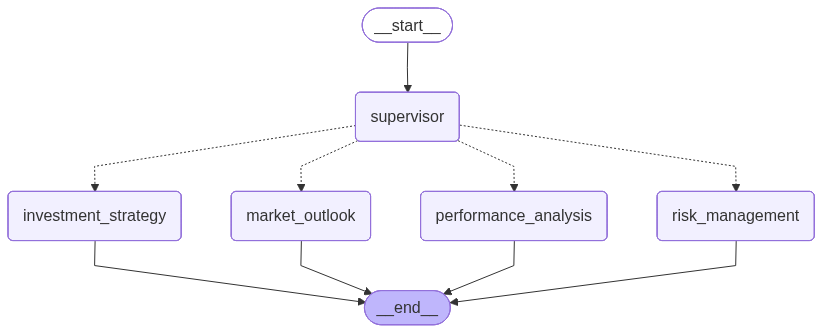

In [24]:
# Visualize the graph
try:
    from IPython.display import display, Image
    display(Image(supervisor_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")
    print("\nGraph structure:")
    print(supervisor_graph.get_graph().draw_ascii())

In [25]:
# Test the supervisor system
print("Testing Supervisor Multi-Agent System")
print("=" * 50)

response = supervisor_graph.invoke({
    "messages": [HumanMessage(content="What is Stone Ridge's view on the current market environment?")]
})

print("\nFinal Response:")
print("=" * 50)
print(response["messages"][-1].content)

Testing Supervisor Multi-Agent System
[Supervisor GPT-5.2] Routing to: market_outlook
  Reason: The question asks for Stone Ridge’s view on the current market environment, which is primarily about macro conditions and market trends—best handled by the market_outlook specialist.
[MARKET_OUTLOOK Agent] Processing request...
[MARKET_OUTLOOK Agent] Response complete.

Final Response:
[MARKET_OUTLOOK SPECIALIST]

The current market environment, as viewed by Stone Ridge, emphasizes caution and the unpredictability of market trends. They highlight that past performance is not a reliable indicator of future results and that actual market conditions can differ significantly from expectations. Stone Ridge does not provide formal investment recommendations and acknowledges the potential for changes in market conditions that could affect their outlook. 

For specific insights or strategies, it is advisable to refer to their latest communications or investor letters, as they may contain more detail

In [26]:
# Test with an investment strategy question
print("Testing with investment strategy question")
print("=" * 50)

response = supervisor_graph.invoke({
    "messages": [HumanMessage(content="How does Stone Ridge approach portfolio construction and asset allocation?")]
})

print("\nFinal Response:")
print("=" * 50)
print(response["messages"][-1].content)

Testing with investment strategy question
[Supervisor GPT-5.2] Routing to: investment_strategy
  Reason: The question is about Stone Ridge’s portfolio construction and asset allocation approach, which squarely falls under investment approach and positioning rather than macro outlook, risk hedging specifics, or performance measurement.
[INVESTMENT_STRATEGY Agent] Processing request...
[INVESTMENT_STRATEGY Agent] Response complete.

Final Response:
[INVESTMENT_STRATEGY SPECIALIST]

The search did not yield specific details on Stone Ridge's approach to portfolio construction, asset allocation, or investment philosophy. However, based on general knowledge, Stone Ridge typically emphasizes a few key principles in their investment strategy:

1. **Long-Term Focus**: They often adopt a long-term investment horizon, seeking to capitalize on market inefficiencies and mispricings.

2. **Diversification**: Stone Ridge tends to diversify across various asset classes to mitigate risk and enhance ret

## Task 4: Adding Tavily Search for Web Research

Sometimes the investment knowledge base doesn't have the latest information. Let's add **Tavily Search** to allow agents to search the web for current market data and financial news.

**Documentation:**
- [Tavily Search Tool](https://python.langchain.com/docs/integrations/tools/tavily_search/)
- [Tavily API Docs](https://docs.tavily.com/)

In [27]:
# Create a Tavily search tool (using updated langchain-tavily package)
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results=3,
    topic="news"
)

print(f"Tavily search tool created: {tavily_search.name}")

Tavily search tool created: tavily_search


In [28]:
# Test Tavily search
search_results = tavily_search.invoke("latest Stone Ridge Asset Management investment performance 2025")
print("Tavily Search Results:")
print("-" * 50)

for result in search_results['results'][:2]:
    print(f"\nTitle: {result.get('title', 'N/A')}")
    print(f"URL: {result.get('url', 'N/A')}")
    print(f"Content: {result.get('content', 'N/A')[:200]}...")

Tavily Search Results:
--------------------------------------------------

Title: Q2 2025 Global Fund Performance Report (with preliminary Q3 2025 data) - PitchBook
URL: https://pitchbook.com/news/reports/q2-2025-global-fund-performance-report-with-preliminary-q3-2025-data
Content: # Global Fund Performance Report (with preliminary Q3 2025 data). *PitchBook clients can access this report’s Excel data pack via the Research Center on the PitchBook Platform.*. **Private markets at ...

Title: Private credit — an unlikely star in Olympics, Super Bowl - PitchBook
URL: https://pitchbook.com/news/articles/private-credit-an-unlikely-star-in-olympics-super-bowl
Content: *   Image 48: 2024_q3_product_PIRG_outlined_icon_navy.svg Latest News News, analysis, and data shaping private markets. *   Image 59: 2025-credit-risk-outlined-navy-icon.svg Credit Insights on private...


In [29]:
# Create a research agent that can search both the investment knowledge base AND the web
@tool
def search_investment_kb(query: str) -> str:
    """Search the local investment knowledge base for information from the Stone Ridge investor letter.
    Use this first for questions about Stone Ridge's investment approach.
    """
    results = retriever.invoke(query)
    if not results:
        return "No information found in knowledge base."
    return "\n\n".join([f"[KB Source {i+1}]: {doc.page_content}" for i, doc in enumerate(results)])

@tool
def search_web_current(query: str) -> str:
    """Search the web for current market news, financial data, and recent investment information.
    Use this when you need the latest market updates or information not in the knowledge base.
    """
    response = tavily_search.invoke(query)
    if not response or not response.get('results'):
        return "No web results found."
    formatted = []
    for i, r in enumerate(response['results'][:3]):
        formatted.append(f"[Web Source {i+1}]: {r.get('content', 'N/A')}\nURL: {r.get('url', 'N/A')}")
    return "\n\n".join(formatted)

# Create a research agent with both tools (using create_agent)
research_agent = create_agent(
    model=specialist_llm,
    tools=[search_investment_kb, search_web_current],
    system_prompt="""You are an Investment Research Agent. You have access to both the Stone Ridge investor letter 
knowledge base and web search. Use the knowledge base for Stone Ridge-specific information and web search 
for current market data. Always cite your sources."""
)

print("Research agent with web search created (using create_agent)!")

Research agent with web search created (using create_agent)!


In [30]:
# Test the research agent
print("Testing Research Agent (KB + Web)")
print("=" * 50)

response = research_agent.invoke({
    "messages": [HumanMessage(content="What are the latest developments in alternative investments and risk management?")]
})

print("\nResearch Agent Response:")
print(response["messages"][-1].content)

Testing Research Agent (KB + Web)

Research Agent Response:
### Latest Developments in Alternative Investments

1. **Tokenization of Assets**: One of the most significant trends in alternative investments is the integration of tokenization. This process allows for the fractional ownership of assets, making it easier for retail investors to access alternative investments. A recent report indicated that assets under management in alternative investments for private wealth investors are expected to triple from $4 trillion to $12 trillion by 2025. This shift is driven by the need for portfolio diversification and the accessibility of alternative assets through digital platforms ([Finextra](https://www.finextra.com/the-long-read/1568/integrating-tokenisation-and-alternative-assets-into-retail-portfolios)).

2. **Regulation A Offerings**: Regulation A, often referred to as "mini-IPOs," is transforming how investors access alternative investments. This regulatory framework allows companies to

---
## Question #1:

In the Supervisor pattern, the supervisor routes requests to specialist agents. What are the **advantages** and **disadvantages** of having agents loop back to the supervisor after responding, versus having them respond directly to the user? Consider this in the context of an investment advisory system where accuracy is critical.

##### Answer:

A disadvantage of looping back would be potentially slower results and more tokens. In a complex system, more routing could cost time and money. It's also possible a second LLM call could misinterpret the results from the specialist agents, or drop important details.

An advantage is that it allows routing to another specialist if needed, based on the returned content of the first specialist. Another is that the specialist can focus on just returning relevant information, while the supervisor could have extra prompting for summarizing results or formatting things for the caller.

## Question #2:

We added Tavily web search alongside the investment knowledge base. In what scenarios would you want to **restrict** an agent to only use the knowledge base (no web search)? What are the trade-offs between freshness and reliability when providing investment information?

##### Answer:

If you only want answers and context from a specific reference body. E.g., you have an internal wiki with best practices for your company, and you don't want an LLM to conflate that with potentially conflicting information from the internet.

Having up-to-date information from the internet can be useful, but it can also have performance trade-offs. It can bloat the context and provide misguided answers if you're looking for something specific.

---
## Activity #1: Add a Custom Investment Specialist Agent

Add a new specialist agent to the supervisor system. Ideas:
- **Regulatory Agent**: Handles regulatory compliance and investment regulations
- **Macro Economic Agent**: Focuses on macroeconomic indicators and economic data
- **ESG Agent**: Addresses ESG criteria and sustainable investing

Requirements:
1. Create a specialized search tool for your agent's domain
2. Create the specialist agent with an appropriate system prompt
3. Add the agent to the supervisor graph
4. Update the routing logic
5. Test with relevant questions

In [47]:
### YOUR CODE HERE ###

# Step 1: Create a specialized search tool
@tool
def search_macroeconomic_data(query: str) -> str:
    """
    Search for macroeconomic data from the Stone Ridge investor letter.
    Use this for questions about worldwide economics, like GDP, imports and exports, tarriffs, etc.
    """
    
    results = retriever.invoke(f"macroeconomic factors and implications {query}")
    
    if not results:
        return "No macroeconomic information found."
        
    return "\n\n".join([f"[Source {i+1}]: {doc.page_content}" for i, doc in enumerate(results)])

# Step 2: Create the specialist agent

macroeconomic_agent = create_agent(
    model=specialist_llm,
    tools=[search_macroeconomic_data],
    system_prompt="You are an Macroeconomic Specialist. Help users with questions about large economic trends, international trade, and domestic fiscal policy, and. Always search the knowledge base before answering. Be concise and data-driven."
)

# Step 3: Add to the supervisor graph (you may need to rebuild the graph)

macroeconomic_node = create_agent_node(macroeconomic_agent, "macroeconomic")

# Create the graph
supervisor_workflow = StateGraph(SupervisorState)

# Add nodes
supervisor_workflow.add_node("supervisor", supervisor_node)
supervisor_workflow.add_node("market_outlook", market_outlook_node)
supervisor_workflow.add_node("investment_strategy", investment_strategy_node)
supervisor_workflow.add_node("risk_management", risk_management_node)
supervisor_workflow.add_node("performance_analysis", performance_analysis_node)
supervisor_workflow.add_node("macroeconomic", macroeconomic_node)

supervisor_workflow.add_edge(START, "supervisor")

# Conditional routing from supervisor to specialists
supervisor_workflow.add_conditional_edges(
    "supervisor",
    route_to_agent,
    {
        "market_outlook": "market_outlook",
        "investment_strategy": "investment_strategy",
        "risk_management": "risk_management",
        "performance_analysis": "performance_analysis",
        "macroeconomic": "macroeconomic",
    }
)

supervisor_workflow.add_edge("market_outlook", END)
supervisor_workflow.add_edge("investment_strategy", END)
supervisor_workflow.add_edge("risk_management", END)
supervisor_workflow.add_edge("performance_analysis", END)
supervisor_workflow.add_edge("macroeconomic", END)

supervisor_graph = supervisor_workflow.compile()

# Step 4: Test your new agent

print("Testing Supervisor Multi-Agent System")
print("=" * 50)

response = supervisor_graph.invoke({
    "messages": [HumanMessage(content="What is Stone Ridge's view on macroeconomics?")]
})

print("\nFinal Response:")
print("=" * 50)
print(response["messages"][-1].content)

Testing Supervisor Multi-Agent System
[Supervisor GPT-5.2] Routing to: macroeconomic
  Reason: The question asks specifically about Stone Ridge’s view on macroeconomics, which is best handled by the macroeconomic specialist focused on broad economic frameworks, policy, and macro drivers.
[MACROECONOMIC Agent] Processing request...
[MACROECONOMIC Agent] Response complete.

Final Response:
[MACROECONOMIC SPECIALIST]

The search did not yield specific insights into Stone Ridge's view on macroeconomics. However, it is important to note that Stone Ridge typically emphasizes a data-driven approach to investment and may focus on various macroeconomic indicators and trends in their analyses. For detailed insights, it would be best to refer directly to their investor letters or official publications.


---
#  🤝 Breakout Room #2
## Handoffs & Context Engineering

## Task 5: Agent Handoffs Pattern

The **Handoffs Pattern** allows agents to transfer control to each other based on the conversation context. Unlike the supervisor pattern, agents decide themselves when to hand off.

```
    User Question
         │
         ▼
    ┌──────────┐  "I need strategy help"  ┌──────────────┐
    │  Market  │ ────────────────────────► │  Investment  │
    │ Outlook  │                           │   Strategy   │
    │  Agent   │ ◄──────────────────────── │    Agent     │
    └──────────┘  "Back to market topics"  └──────────────┘
```

**Documentation:**
- [LangGraph Agent Handoffs](https://langchain-ai.github.io/langgraph/how-tos/agent-handoffs/)

In [48]:
# Create handoff tools that agents can use to transfer control
# Each tool returns a special HANDOFF string that the graph will detect

@tool
def transfer_to_market_outlook(reason: str) -> str:
    """Transfer to Market Outlook Specialist for market trends, economic conditions, and macro environment questions.
    
    Args:
        reason: Why you're transferring to this specialist
    """
    return f"HANDOFF:market_outlook:{reason}"

@tool
def transfer_to_investment_strategy(reason: str) -> str:
    """Transfer to Investment Strategy Specialist for portfolio positioning, asset allocation, and investment approach questions.
    
    Args:
        reason: Why you're transferring to this specialist
    """
    return f"HANDOFF:investment_strategy:{reason}"

@tool
def transfer_to_risk_management(reason: str) -> str:
    """Transfer to Risk Management Specialist for risk factors, tail risks, hedging, and diversification questions.
    
    Args:
        reason: Why you're transferring to this specialist
    """
    return f"HANDOFF:risk_management:{reason}"

@tool
def transfer_to_performance_analysis(reason: str) -> str:
    """Transfer to Performance Analysis Specialist for returns, benchmarks, and performance metrics questions.
    
    Args:
        reason: Why you're transferring to this specialist
    """
    return f"HANDOFF:performance_analysis:{reason}"

print("Handoff tools created!")

Handoff tools created!


In [49]:
# Create agents with handoff capabilities (using create_agent)

market_outlook_handoff_agent = create_agent(
    model=specialist_llm,
    tools=[
        search_market_outlook,
        transfer_to_investment_strategy,
        transfer_to_risk_management,
        transfer_to_performance_analysis
    ],
    system_prompt="""You are a Market Outlook Specialist. Answer questions about market trends, economic conditions, and the macro environment.
If the user's question is better suited for another specialist, use the appropriate transfer tool.
Always search the knowledge base before answering market outlook questions."""
)

investment_strategy_handoff_agent = create_agent(
    model=specialist_llm,
    tools=[
        search_investment_strategy,
        transfer_to_market_outlook,
        transfer_to_risk_management,
        transfer_to_performance_analysis
    ],
    system_prompt="""You are an Investment Strategy Specialist. Answer questions about portfolio positioning, asset allocation, and investment philosophy.
If the user's question is better suited for another specialist, use the appropriate transfer tool.
Always search the knowledge base before answering investment strategy questions."""
)

risk_management_handoff_agent = create_agent(
    model=specialist_llm,
    tools=[
        search_risk_info,
        transfer_to_market_outlook,
        transfer_to_investment_strategy,
        transfer_to_performance_analysis
    ],
    system_prompt="""You are a Risk Management Specialist. Answer questions about risk factors, tail risks, hedging, and diversification.
If the user's question is better suited for another specialist, use the appropriate transfer tool.
Always search the knowledge base before answering risk management questions."""
)

performance_analysis_handoff_agent = create_agent(
    model=specialist_llm,
    tools=[
        search_performance_info,
        transfer_to_market_outlook,
        transfer_to_investment_strategy,
        transfer_to_risk_management
    ],
    system_prompt="""You are a Performance Analysis Specialist. Answer questions about investment returns, benchmarks, and performance metrics.
If the user's question is better suited for another specialist, use the appropriate transfer tool.
Always search the knowledge base before answering performance analysis questions."""
)

print("Handoff-enabled agents created (using create_agent)!")

Handoff-enabled agents created (using create_agent)!


In [50]:
# Build the handoff graph with transfer limit to prevent infinite loops

class HandoffState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    current_agent: str
    transfer_count: int  # Track transfers to prevent infinite loops

MAX_TRANSFERS = 2  # Maximum number of handoffs allowed

def parse_handoff(content: str) -> tuple[bool, str, str]:
    """Parse a handoff from agent response."""
    if "HANDOFF:" in content:
        parts = content.split("HANDOFF:")[1].split(":")
        return True, parts[0], parts[1] if len(parts) > 1 else ""
    return False, "", ""

def create_handoff_node(agent, name: str):
    """Create a node that can handle handoffs."""
    def node(state: HandoffState):
        print(f"[{name.upper()} Agent] Processing...")
        result = agent.invoke({"messages": state["messages"]})
        last_message = result["messages"][-1]
        
        # Check for handoff in tool messages (only if under transfer limit)
        if state["transfer_count"] < MAX_TRANSFERS:
            for msg in result["messages"]:
                if hasattr(msg, 'content') and "HANDOFF:" in str(msg.content):
                    is_handoff, target, reason = parse_handoff(str(msg.content))
                    if is_handoff:
                        print(f"[{name.upper()}] Handing off to {target}: {reason}")
                        return {
                            "messages": [AIMessage(content=f"[{name}] Transferring to {target} specialist: {reason}")],
                            "current_agent": target,
                            "transfer_count": state["transfer_count"] + 1
                        }
        
        # No handoff (or limit reached), return final response
        response = AIMessage(
            content=f"[{name.upper()} SPECIALIST]\n\n{last_message.content}",
            name=name
        )
        print(f"[{name.upper()} Agent] Response complete.")
        return {"messages": [response], "current_agent": "done", "transfer_count": state["transfer_count"]}
    
    return node

# Create nodes
market_outlook_handoff_node = create_handoff_node(market_outlook_handoff_agent, "market_outlook")
investment_strategy_handoff_node = create_handoff_node(investment_strategy_handoff_agent, "investment_strategy")
risk_management_handoff_node = create_handoff_node(risk_management_handoff_agent, "risk_management")
performance_analysis_handoff_node = create_handoff_node(performance_analysis_handoff_agent, "performance_analysis")

print("Handoff nodes created!")

Handoff nodes created!


In [51]:
# Build the handoff graph with initial routing (using GPT-5.2)

def entry_router(state: HandoffState):
    """Initial routing based on the user's question (using GPT-5.2)."""
    user_question = state['messages'][-1].content
    
    router_prompt = f"""Based on this question, which specialist should handle it?
Options: market_outlook, investment_strategy, risk_management, performance_analysis

Question: {user_question}

Respond with just the specialist name (one word or underscore-separated)."""
    
    response = supervisor_llm.invoke(router_prompt)
    agent = response.content.strip().lower()
    
    # Validate
    if agent not in ["market_outlook", "investment_strategy", "risk_management", "performance_analysis"]:
        agent = "market_outlook"  # Default to market outlook for general questions
    
    print(f"[Router GPT-5.2] Initial routing to: {agent}")
    return {"current_agent": agent, "transfer_count": 0}

def route_by_current_agent(state: HandoffState) -> str:
    """Route based on current_agent field."""
    return state["current_agent"]

# Build graph
handoff_workflow = StateGraph(HandoffState)

# Add nodes
handoff_workflow.add_node("router", entry_router)
handoff_workflow.add_node("market_outlook", market_outlook_handoff_node)
handoff_workflow.add_node("investment_strategy", investment_strategy_handoff_node)
handoff_workflow.add_node("risk_management", risk_management_handoff_node)
handoff_workflow.add_node("performance_analysis", performance_analysis_handoff_node)

# Entry point
handoff_workflow.add_edge(START, "router")

# Router to agents
handoff_workflow.add_conditional_edges(
    "router",
    route_by_current_agent,
    {
        "market_outlook": "market_outlook",
        "investment_strategy": "investment_strategy",
        "risk_management": "risk_management",
        "performance_analysis": "performance_analysis"
    }
)

# Agents can handoff to each other or end
for agent_name in ["market_outlook", "investment_strategy", "risk_management", "performance_analysis"]:
    handoff_workflow.add_conditional_edges(
        agent_name,
        route_by_current_agent,
        {
            "market_outlook": "market_outlook",
            "investment_strategy": "investment_strategy",
            "risk_management": "risk_management",
            "performance_analysis": "performance_analysis",
            "done": END
        }
    )

# Compile
handoff_graph = handoff_workflow.compile()

print("Handoff multi-agent system built!")

Handoff multi-agent system built!


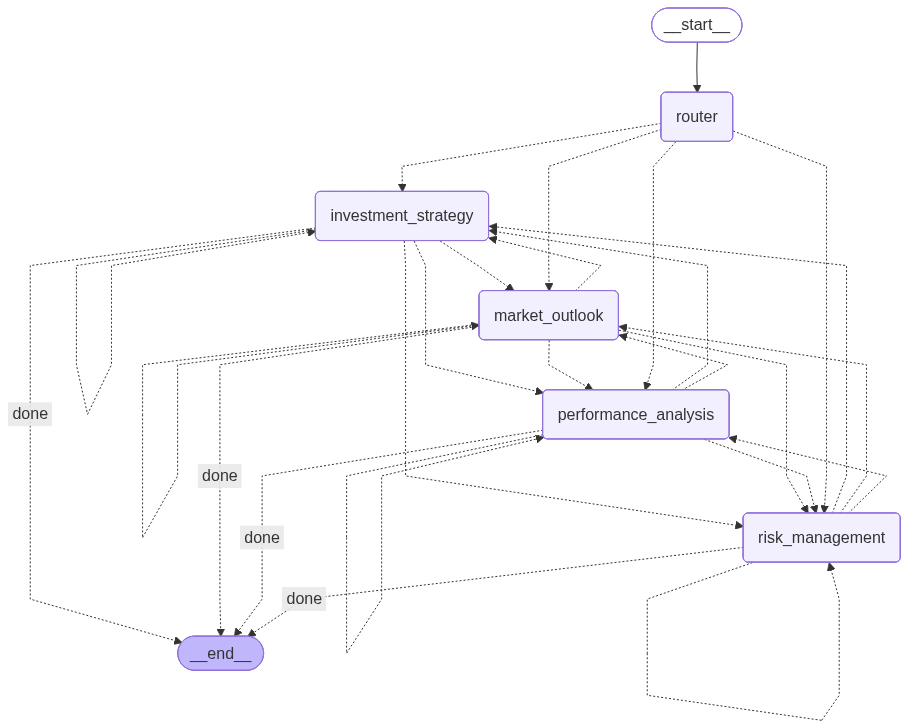

In [52]:
# Visualize the handoff graph
try:
    from IPython.display import display, Image
    display(Image(handoff_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not display graph: {e}")
    print("\nGraph structure:")
    print(handoff_graph.get_graph().draw_ascii())

In [53]:
# Test the handoff system
print("Testing Handoff System")
print("=" * 50)

response = handoff_graph.invoke({
    "messages": [HumanMessage(content="I'm concerned about market volatility and want to understand the risk in my portfolio. What should I do?")],
    "current_agent": "",
    "transfer_count": 0
})

print("\n" + "=" * 50)
print("FINAL RESPONSE:")
print("=" * 50)
print(response["messages"][-1].content)

Testing Handoff System
[Router GPT-5.2] Initial routing to: risk_management
[RISK_MANAGEMENT Agent] Processing...
[RISK_MANAGEMENT] Handing off to market_outlook: The user is concerned about market volatility and wants to understand the risk in their portfolio, which is better suited for a Market Outlook Specialist.
[MARKET_OUTLOOK Agent] Processing...
[MARKET_OUTLOOK] Handing off to risk_management: The user is concerned about market volatility and wants to understand the risk in their portfolio.
[RISK_MANAGEMENT Agent] Processing...
[RISK_MANAGEMENT Agent] Response complete.

FINAL RESPONSE:
[RISK_MANAGEMENT SPECIALIST]

I've transferred your question to a Market Outlook Specialist who can provide insights on market volatility and help you understand the risk in your portfolio. They will be able to assist you further.


## Task 6: Building an Investment Agent Team

Now let's combine what we've learned to build a complete investment team that can:
1. Handle complex multi-domain investment questions
2. Search both the knowledge base and the web
3. Maintain conversation context
4. Provide comprehensive investment advisory guidance

In [54]:
# Create a unified investment team with memory
from langgraph.checkpoint.memory import MemorySaver

# Add memory to the supervisor graph
memory = MemorySaver()

supervisor_with_memory = supervisor_workflow.compile(checkpointer=memory)

print("Supervisor with memory created!")

Supervisor with memory created!


In [55]:
# Test multi-turn conversation
thread_id = "investment-session-1"
config = {"configurable": {"thread_id": thread_id}}

print("Multi-turn Conversation Test")
print("=" * 50)

# First question
response1 = supervisor_with_memory.invoke(
    {"messages": [HumanMessage(content="What is Stone Ridge's investment philosophy?")]},
    config=config
)
print("\n[Turn 1 Response]:")
print(response1["messages"][-1].content[:500])

Multi-turn Conversation Test
[Supervisor GPT-5.2] Routing to: investment_strategy
  Reason: The user is asking about an investment philosophy, which aligns most directly with investment approach and portfolio positioning rather than macro, market outlook, risk hedging, or performance measurement.
[INVESTMENT_STRATEGY Agent] Processing request...
[INVESTMENT_STRATEGY Agent] Response complete.

[Turn 1 Response]:
[INVESTMENT_STRATEGY SPECIALIST]

The search did not yield specific details about Stone Ridge's investment philosophy. However, based on general knowledge, Stone Ridge typically emphasizes a value-oriented investment approach, focusing on long-term fundamentals and risk management. They often utilize alternative investment strategies and seek to align their interests with those of their investors, emphasizing transparency and a principled investment process. 

For precise details, I recommend ch


In [56]:
# Follow-up question (should remember context)
response2 = supervisor_with_memory.invoke(
    {"messages": [HumanMessage(content="How do they manage risk in their portfolio?")]},
    config=config
)
print("\n[Turn 2 Response]:")
print(response2["messages"][-1].content[:500])

[Supervisor GPT-5.2] Routing to: risk_management
  Reason: The question asks specifically about how portfolio risk is managed (risk controls, hedging, diversification, limits), which falls squarely under the risk_management specialist.
[RISK_MANAGEMENT Agent] Processing request...
[RISK_MANAGEMENT Agent] Response complete.

[Turn 2 Response]:
[RISK_MANAGEMENT SPECIALIST]

Stone Ridge manages risk in their portfolio through several strategies:

1. **Selective Investment**: They focus on hyper-selective investments, particularly in areas where they can identify clear strategic advantages, such as legacy reinsurance.

2. **Long-Term Focus**: By maintaining a long-term perspective, they aim to mitigate short-term volatility and focus on fundamental value.

3. **Diversification**: They diversify their investments across various asset clas


## Task 7: Context Engineering & Optimization

As conversations grow, we need to manage context carefully. Key principles:

1. **Context Window as Prime Real Estate**: Only include what's necessary
2. **Summarization**: Compress long conversations
3. **Selective Retrieval**: Don't retrieve everything, just what's relevant
4. **Context Rot**: More tokens doesn't mean better performance

In [57]:
# Implement a context summarization function (using GPT-4o-mini for cost efficiency)
# This helps manage context length in multi-turn investment advisory conversations

def summarize_conversation(messages: list[BaseMessage], max_messages: int = 6) -> list[BaseMessage]:
    """Summarize older messages to manage context length."""
    if len(messages) <= max_messages:
        return messages
    
    # Keep the first message (original question) and last few messages
    old_messages = messages[1:-max_messages+1]
    recent_messages = messages[-max_messages+1:]
    
    # Summarize old messages
    summary_prompt = f"""Summarize this conversation history in 2-3 sentences, 
capturing the key topics discussed and any important decisions made:

{chr(10).join([f'{m.type}: {m.content[:200]}' for m in old_messages])}"""
    
    summary = specialist_llm.invoke(summary_prompt)
    
    # Return: first message + summary + recent messages
    return [
        messages[0],
        SystemMessage(content=f"[Previous conversation summary: {summary.content}]"),
        *recent_messages
    ]

print("Context summarization function created!")

Context summarization function created!


In [58]:
# Demonstrate context optimization
sample_messages = [
    HumanMessage(content="I want to understand Stone Ridge's investment approach"),
    AIMessage(content="Great question! Let's start with their philosophy."),
    HumanMessage(content="What about their risk management?"),
    AIMessage(content="Stone Ridge focuses on tail risk hedging..."),
    HumanMessage(content="How have they performed?"),
    AIMessage(content="Their performance has been..."),
    HumanMessage(content="What about portfolio construction?"),
    AIMessage(content="For portfolio construction..."),
    HumanMessage(content="What's their outlook for the current market?"),
]

print(f"Original messages: {len(sample_messages)}")

optimized = summarize_conversation(sample_messages, max_messages=4)
print(f"Optimized messages: {len(optimized)}")
print("\nOptimized conversation:")
for msg in optimized:
    print(f"  [{msg.type}]: {msg.content[:100]}...")

Original messages: 9
Optimized messages: 5

Optimized conversation:
  [human]: I want to understand Stone Ridge's investment approach...
  [system]: [Previous conversation summary: The conversation focused on the investment philosophy and risk manag...
  [human]: What about portfolio construction?...
  [ai]: For portfolio construction......
  [human]: What's their outlook for the current market?...


---
## Question #3:

Compare the **Supervisor pattern** and the **Handoffs pattern** we implemented. What are the key differences in how routing decisions are made? When would you choose one pattern over the other for an investment advisory system?

##### Answer:

In the supervisor pattern, the specialist agents only had the single tool that they needed to answer specialized questions. In the handoffs pattern, they also had tools that helped determine if other specialists would be better suited to answer some or all of the question.

The handoffs pattern is more complex, and requires setting up more tools to make it work. It also means the specialist agents are less specialized and do more of the routing. If you want to keep all the routing moving through the supervisor (e.g., to more easily track when that happens, summarize context along the way, etc.), it might be better to use the supervisor pattern.

## Question #4:

We discussed "Context Rot" - the idea that longer context doesn't always mean better performance. How does this principle apply to multi-agent investment advisory systems? What strategies can you use to manage context effectively when dealing with complex financial information?

##### Answer:

As agents pass context between each other, it can grow with each agent call, expanding as it goes. This can cause content rot more quickly than a in a single agent system.

Summarizing context is one way to limit rot in a system like this. Another would be to use conditional routing to limit the number of handoffs, or to send context to a summarizing agent if it gets too large.

---
## Activity #2: Implement Hierarchical Teams

Build a **Hierarchical Agent System** where a top-level supervisor manages multiple team supervisors, each with their own specialist agents.

### Requirements:

1. Create an **Investment Director** (top-level supervisor using GPT-5.2) that:
   - Receives user questions and determines which team should handle it
   - Routes to either the "Markets Team" or "Strategy Team"
   - Aggregates final responses from teams

2. Create two **Team Supervisors**:
   - **Markets Team Lead**: Manages Market Outlook Agent and Performance Analysis Agent
   - **Strategy Team Lead**: Manages Investment Strategy Agent and Risk Management Agent

3. Implement the hierarchical routing:
   - User question -> Investment Director -> Team Lead -> Specialist Agent -> Response

4. Test with questions that require different teams:
   - "What is Stone Ridge's view on the current market environment?" (Markets team)
   - "How does Stone Ridge manage tail risk in its portfolios?" (Strategy team)

### Architecture:
```
                    ┌──────────────────────┐
                    │ Investment Director  │
                    │      (GPT-5.2)      │
                    └──────────┬───────────┘
                               │
              ┌────────────────┴────────────────┐
              │                                 │
              ▼                                 ▼
   ┌─────────────────────┐          ┌─────────────────────┐
   │   Markets Team      │          │   Strategy Team     │
   │     Lead            │          │     Lead            │
   └──────────┬──────────┘          └──────────┬──────────┘
              │                                 │
       ┌──────┴──────┐                   ┌──────┴──────┐
       │             │                   │             │
       ▼             ▼                   ▼             ▼
  ┌──────────┐ ┌────────────┐    ┌────────────┐ ┌──────────┐
  │ Market   │ │Performance │    │ Investment │ │   Risk   │
  │ Outlook  │ │ Analysis   │    │  Strategy  │ │Management│
  │  Agent   │ │   Agent    │    │   Agent    │ │  Agent   │
  └──────────┘ └────────────┘    └────────────┘ └──────────┘
```

**Documentation:**
- [LangGraph Hierarchical Teams](https://langchain-ai.github.io/langgraph/tutorials/multi_agent/hierarchical_agent_teams/)

In [59]:
### YOUR CODE HERE ###

# Step 1: Create Team Supervisors (using GPT-5.2 for routing)
# These manage routing within their teams

class TeamRouterOutput(BaseModel):
    """Team supervisor routing decision."""
    next: str  # The specialist to route to within the team
    reasoning: str

# Markets Team Lead
markets_team_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are the Markets Team Lead.
Your team has two specialists:
- market_outlook: Handles market trends, economic conditions, and macro environment
- performance_analysis: Handles returns, benchmarks, and performance metrics

Route to the most appropriate specialist for the user's question."""),
    ("human", "Question: {question}")
])

# Strategy Team Lead  
strategy_team_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are the Strategy Team Lead.
Your team has two specialists:
- investment_strategy: Handles portfolio positioning, asset allocation, and investment philosophy
- risk_management: Handles risk factors, tail risks, hedging, and diversification

Route to the most appropriate specialist for the user's question."""),
    ("human", "Question: {question}")
])

# Step 2: Create the Investment Director (top-level, using GPT-5.2)
class DirectorRouterOutput(BaseModel):
    """Director routing decision to teams."""
    team: Literal["markets", "strategy"]
    reasoning: str

director_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are the Investment Director overseeing two teams:
- markets: Markets Team (market outlook, performance analysis)
- strategy: Strategy Team (investment strategy, risk management)

Route to the appropriate team based on the user's question."""),
    ("human", "Question: {question}")
])

# Step 3: Build the hierarchical graph
# Hint: You'll need nested graphs or a state that tracks the current level

class HierarchicalState(TypedDict):
    """State for hierarchical multi-agent system."""
    messages: Annotated[list[BaseMessage], add_messages]
    current_team: str  # "markets" or "strategy"
    current_agent: str  # specialist agent name

# Create LLMs with structured output for routing
director_routing_llm = supervisor_llm.with_structured_output(DirectorRouterOutput)
markets_team_routing_llm = supervisor_llm.with_structured_output(TeamRouterOutput)
strategy_team_routing_llm = supervisor_llm.with_structured_output(TeamRouterOutput)

def director_node(state: HierarchicalState):
    """Investment Director routes to teams."""
    # Get user question
    user_question = ""
    for msg in reversed(state["messages"]):
        if isinstance(msg, HumanMessage):
            user_question = msg.content
            break
    
    # Route to team
    prompt_value = director_prompt.invoke({"question": user_question})
    result = director_routing_llm.invoke(prompt_value)
    
    print(f"[DIRECTOR GPT-5.2] Routing to team: {result.team}")
    print(f"  Reason: {result.reasoning}")
    
    return {"current_team": result.team}

def markets_team_lead_node(state: HierarchicalState):
    """Markets Team Lead routes to specialists."""
    user_question = ""
    for msg in reversed(state["messages"]):
        if isinstance(msg, HumanMessage):
            user_question = msg.content
            break
    
    prompt_value = markets_team_prompt.invoke({"question": user_question})
    result = markets_team_routing_llm.invoke(prompt_value)
    
    print(f"[MARKETS TEAM LEAD GPT-5.2] Routing to: {result.next}")
    print(f"  Reason: {result.reasoning}")
    
    return {"current_agent": result.next}

def strategy_team_lead_node(state: HierarchicalState):
    """Strategy Team Lead routes to specialists."""
    user_question = ""
    for msg in reversed(state["messages"]):
        if isinstance(msg, HumanMessage):
            user_question = msg.content
            break
    
    prompt_value = strategy_team_prompt.invoke({"question": user_question})
    result = strategy_team_routing_llm.invoke(prompt_value)
    
    print(f"[STRATEGY TEAM LEAD GPT-5.2] Routing to: {result.next}")
    print(f"  Reason: {result.reasoning}")
    
    return {"current_agent": result.next}

# Create wrapper nodes for specialist agents
def create_hierarchical_agent_node(agent, name: str):
    """Create a node for specialist agents in hierarchical system."""
    def agent_node(state: HierarchicalState):
        print(f"[{name.upper()} SPECIALIST] Processing request...")
        
        result = agent.invoke({"messages": state["messages"]})
        agent_response = result["messages"][-1]
        
        response_with_name = AIMessage(
            content=f"[{name.upper()} SPECIALIST]\n\n{agent_response.content}",
            name=name
        )
        
        print(f"[{name.upper()} SPECIALIST] Response complete.")
        return {"messages": [response_with_name]}
    
    return agent_node

# Create specialist nodes
hierarchical_market_outlook = create_hierarchical_agent_node(market_outlook_agent, "market_outlook")
hierarchical_performance_analysis = create_hierarchical_agent_node(performance_analysis_agent, "performance_analysis")
hierarchical_investment_strategy = create_hierarchical_agent_node(investment_strategy_agent, "investment_strategy")
hierarchical_risk_management = create_hierarchical_agent_node(risk_management_agent, "risk_management")

# Routing functions
def route_to_team(state: HierarchicalState) -> str:
    """Route from director to team lead."""
    return state["current_team"]

def route_to_agent(state: HierarchicalState) -> str:
    """Route from team lead to specialist."""
    return state["current_agent"]

# Build the graph
hierarchical_workflow = StateGraph(HierarchicalState)

# Add nodes
hierarchical_workflow.add_node("director", director_node)
hierarchical_workflow.add_node("markets_team_lead", markets_team_lead_node)
hierarchical_workflow.add_node("strategy_team_lead", strategy_team_lead_node)
hierarchical_workflow.add_node("market_outlook", hierarchical_market_outlook)
hierarchical_workflow.add_node("performance_analysis", hierarchical_performance_analysis)
hierarchical_workflow.add_node("investment_strategy", hierarchical_investment_strategy)
hierarchical_workflow.add_node("risk_management", hierarchical_risk_management)

# Add edges: START -> Director
hierarchical_workflow.add_edge(START, "director")

# Director -> Team Leads
hierarchical_workflow.add_conditional_edges(
    "director",
    route_to_team,
    {
        "markets": "markets_team_lead",
        "strategy": "strategy_team_lead"
    }
)

# Markets Team Lead -> Specialists
hierarchical_workflow.add_conditional_edges(
    "markets_team_lead",
    route_to_agent,
    {
        "market_outlook": "market_outlook",
        "performance_analysis": "performance_analysis"
    }
)

# Strategy Team Lead -> Specialists
hierarchical_workflow.add_conditional_edges(
    "strategy_team_lead",
    route_to_agent,
    {
        "investment_strategy": "investment_strategy",
        "risk_management": "risk_management"
    }
)

# Specialists -> END
hierarchical_workflow.add_edge("market_outlook", END)
hierarchical_workflow.add_edge("performance_analysis", END)
hierarchical_workflow.add_edge("investment_strategy", END)
hierarchical_workflow.add_edge("risk_management", END)

# Compile
hierarchical_graph = hierarchical_workflow.compile()

print("Hierarchical multi-agent system built!")
print("Flow: User -> Director -> Team Lead -> Specialist -> END")

# Step 4: Test the hierarchical system
print("\n" + "=" * 70)
print("TEST 1: Markets Team Question")
print("=" * 70)

test_question = "What is Stone Ridge's view on the current market environment?"
response = hierarchical_graph.invoke({
    "messages": [HumanMessage(content=test_question)],
    "current_team": "",
    "current_agent": ""
})

print("\nFinal Response:")
print("-" * 70)
print(response["messages"][-1].content)

print("\n" + "=" * 70)
print("TEST 2: Strategy Team Question")
print("=" * 70)

test_question = "How does Stone Ridge manage tail risk in its portfolios?"
response = hierarchical_graph.invoke({
    "messages": [HumanMessage(content=test_question)],
    "current_team": "",
    "current_agent": ""
})

print("\nFinal Response:")
print("-" * 70)
print(response["messages"][-1].content)

Hierarchical multi-agent system built!
Flow: User -> Director -> Team Lead -> Specialist -> END

TEST 1: Markets Team Question
[DIRECTOR GPT-5.2] Routing to team: markets
  Reason: The user is asking for Stone Ridge’s view on the current market environment, which is a market outlook/performance context question handled by the Markets Team.
[MARKETS TEAM LEAD GPT-5.2] Routing to: market_outlook
  Reason: The user asks for Stone Ridge's view on the current market environment, which is a request about market trends, economic conditions, and the macro backdrop rather than performance metrics. This fits the market_outlook specialist.
[MARKET_OUTLOOK SPECIALIST] Processing request...
[MARKET_OUTLOOK SPECIALIST] Response complete.

Final Response:
----------------------------------------------------------------------
[MARKET_OUTLOOK SPECIALIST]

The current market environment, as viewed by Stone Ridge, emphasizes the uncertainty and variability of market conditions. They highlight that histor

---
## Summary

In this module, we:

1. **Understood Multi-Agent Systems**: When to use them and key patterns
2. **Built a Supervisor Pattern**: Central orchestrator routing to investment specialists
3. **Implemented Agent Handoffs**: Investment agents transferring control to each other
4. **Added Web Search**: Tavily for current market data alongside the Stone Ridge knowledge base
5. **Applied Context Engineering**: Managing context for optimal performance with financial information

### Key Takeaways:

- **Don't over-engineer**: Only add agents when you truly need specialization
- **Context is key**: Manage your context window carefully, especially with dense financial data
- **Patterns matter**: Choose the right pattern for your investment advisory use case

**Further Reading:**
- [Building Effective Agents (Anthropic)](https://www.anthropic.com/engineering/building-effective-agents)
- [Don't Build Multi-Agents (Cognition)](https://cognition.ai/blog/dont-build-multi-agents)
- [12-Factor Agents](https://github.com/humanlayer/12-factor-agents)